Sto schifo va reso presentabile

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import plotly.graph_objects as go
import math
import textwrap
import spiderplot as sp
import holoviews as hv
from holoviews import opts
from pathlib import Path

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

Load the pre- processed dataset

In [15]:
df = pd.read_csv('Datasets/Processed/Erasmus-Data.csv', index_col=0, low_memory=False)
df = df.reset_index(drop=True)
print(df.shape)
df.head()

(3172958, 14)


,Academic Year,Mobility Duration,Field of Education,Participant Country,Education Level,Participant Gender,Fewer Opportunities,Participant Age,Sending Country,Sending City,Sending Organization,Receiving Country,Receiving City,Receiving Organization
0,2023,61,Business and administration,Austria,ISCED-6 - First cycle / Bachelor’s or equivale...,Female,0,22,Austria,WIEN,WU,Germany,Munich,-
1,2023,101,Economics,Germany,ISCED-7 - Second cycle / Master’s or equivalen...,Male,0,27,Austria,WIEN,WU,France,Toulouse,Université Toulouse Capitole
2,2023,121,Business and administration,Austria,ISCED-6 - First cycle / Bachelor’s or equivale...,Female,0,22,Austria,WIEN,WU,France,Paris,-
3,2023,171,Business and administration,Germany,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,0,22,Austria,WIEN,WU,France,Paris,-
4,2023,86,Business and administration,Austria,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,0,23,Austria,WIEN,WU,Germany,Hamburg,-


## 2. Analisi Esplorativa e Visualizzazione
*Durata : 12 minuti*

Ripetiamo lo stesso set di analisi - collegate alle 3 domande della sezione 0 - su tre livelli
via via piu specifici: **Europa -> Italia -> UMIL**, arricchendo ogni livello con una feature
specifica ().


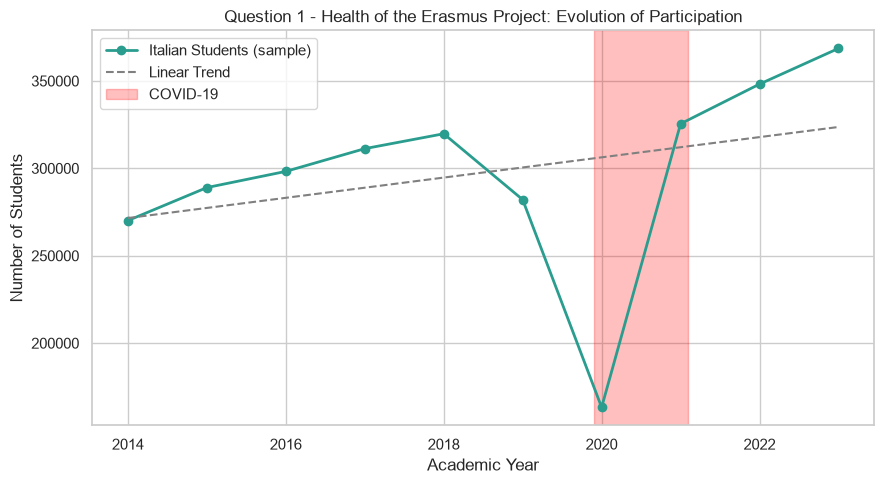

In [16]:
yearly = df
yearly = yearly.groupby('Academic Year').size().reindex(range(2014,2024), fill_value=0)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(yearly.index, yearly.values, marker='o', color='#2a9d8f', linewidth=2, label='Italian Students (sample)')
z = np.polyfit(yearly.index, yearly.values, 1)
ax.plot(yearly.index, np.poly1d(z)(yearly.index), '--', color='gray', label='Linear Trend')
ax.axvspan(2019.9, 2021.1, color='red', alpha=0.25, label='COVID-19')
ax.set_title('Question 1 - Health of the Erasmus Project: Evolution of Participation')
ax.set_xlabel('Academic Year'); ax.set_ylabel('Number of Students'); ax.legend()

plt.tight_layout();
plt.savefig("Plots/Question 1 - Health of the Erasmus Project.png", dpi=800, bbox_inches="tight")
plt.show()

Una cosa da notare è che i dati di ogni singolo anno sono di fatto divisi tra il dataset dell'anno corrente e quello dell'anno successivo

Beginning of Chloropeth Map

Bla Bla Bla about Chloropeth

In [17]:
# Build per-year incoming-student counts

years = sorted(df["Academic Year"].astype(str).str[:4].astype(int).unique())

incoming_by_year = {}
for year in years:
    df_year = df[df["Academic Year"].astype(str).str[:4].astype(int) == year]
    incoming = (
        df_year.groupby("Receiving Country")
               .size()
               .reset_index(name="incoming")
               .rename(columns={"Receiving Country": "Country"})
    )
    incoming_by_year[year] = incoming


# Load and clean the map geometry
world = gpd.read_file("Datasets/ne_110m_admin_0_countries.zip")

# Standardize names across shapefile definitions
world["NAME"] = world["NAME"].replace({
    "Türkiye": "Turkey", 
    "Czechia": "Czech Republic",
    "Bosnia and Herz.": "Bosnia and Herzegovina",
    "Russian Federation": "Russia",
    "Moldova, Republic of": "Moldova"
})

europe_list = [
    "Albania", "Andorra", "Austria", "Belgium", "Bosnia and Herzegovina", "Bulgaria",
    "Croatia", "Cyprus", "Czech Republic", "Denmark", "Estonia", "Finland", "France", "Germany",
    "Greece", "Hungary", "Iceland", "Ireland", "Italy", "Kosovo", "Latvia", "Liechtenstein",
    "Lithuania", "Luxembourg", "Malta", "Moldova", "Monaco", "Montenegro", "Netherlands",
    "North Macedonia", "Norway", "Poland", "Portugal", "Romania", "San Marino", "Serbia",
    "Slovakia", "Slovenia", "Spain", "Sweden", "Switzerland", "Turkey", "Ukraine", "United Kingdom",
    "Vatican"
]
europe = world[world["NAME"].isin(europe_list)].copy()


# Global Color Scale settings
GLOBAL_MAX = max(d["incoming"].max() for d in incoming_by_year.values() if not d.empty)
GLOBAL_MAX = math.ceil(GLOBAL_MAX / 1000) * 1000

COLORSCALE = "YlOrRd"  
COUNTRY_LINE_COLOR = "white"


# Build year data
def build_year_data(year):
    year_df = incoming_by_year[year].copy()
    
    merged = europe.merge(year_df, left_on="NAME", right_on="Country", how="left")
    merged = merged.sort_values("NAME").reset_index(drop=True)
    
    merged["hover"] = (
        "<b>" + merged["NAME"] + "</b><br>" +
        "Incoming students: " + 
        merged["incoming"].apply(lambda x: f"{int(x):,}" if pd.notna(x) else "No data")
    )
    return merged

frames_data = {year: build_year_data(year) for year in years}

def make_trace(data_year, showscale=True):
    return go.Choropleth(
        locations=data_year["NAME"],
        z=data_year["incoming"],
        text=data_year["hover"],
        hovertemplate="%{text}<extra></extra>",
        locationmode="country names",
        colorscale=COLORSCALE,
        zmin=0,
        zmax=GLOBAL_MAX,
        marker_line_color=COUNTRY_LINE_COLOR,
        marker_line_width=0.8,
        showscale=showscale,
        colorbar=dict(
            title=dict(text="Students", font=dict(size=12, color="#444")),
            thickness=15,
            len=0.9,
            x=0.92,
            y=0.5,
            yanchor="middle",
            tickfont=dict(size=11, color="#555"),
            outlinewidth=0,
        ),
    )


# Frames (Dynamic Title Updates)
frames = []
for year in years:
    frames.append(
        go.Frame(
            data=[make_trace(frames_data[year])],
            name=str(year),
            layout=go.Layout(
                # Update the layout title dynamically for each year frame
                title=dict(
                    text=f"<b>Incoming Erasmus Students per Country A.Y. {year}</b>"
                )
            ),
        )
    )

first_year = years[0]
fig = go.Figure(
    data=[make_trace(frames_data[first_year])],
    frames=frames,
)

# Global Layout Configuration
fig.update_layout(
    title=dict(
        text=f"<b>Incoming Erasmus Students per Country A.Y. {first_year}</b>",
        x=0.5, xanchor="center", y=0.94,
        font=dict(size=22, family="Arial", color="#2b2b2b"),
    ),
    font=dict(family="Helvetica Neue, Arial", color="#2b2b2b"),
    paper_bgcolor="white",
    plot_bgcolor="white",
    width=1000,
    height=750,
    margin=dict(l=30, r=30, t=110, b=20),

    geo=dict(
        showframe=False,
        showcoastlines=False,
        showcountries=True,
        countrycolor="white",
        showland=True,
        landcolor="#eef0f2",   
        showocean=False,
        projection_type="natural earth",
        center=dict(lat=53, lon=15),
        lataxis_range=[34, 71],   
        lonaxis_range=[-22, 45],  
        bgcolor="white",
    ),

    sliders=[{
        "active": 0,
        "currentvalue": {
            "prefix": "Academic Year: ",
            "font": {"size": 13, "family": "Arial"},
        },
        "pad": {"t": 30, "b": 15},
        "x": 0.12, "len": 0.76,
        "transition": {"duration": 400, "easing": "cubic-in-out"},
        "steps": [
            {
                "method": "animate",
                "args": [[str(year)], {
                    "frame": {"duration": 400, "redraw": True},
                    "mode": "immediate",
                    "transition": {"duration": 400},
                }],
                "label": str(year),
            }
            for year in years
        ],
    }],

    updatemenus=[{
        "type": "buttons",
        "direction": "left",
        "x": 0.12, "y": 0.02,
        "xanchor": "left", "yanchor": "bottom",
        "showactive": False,
        "font": {"size": 12, "family": "Arial"},
        "bgcolor": "white",
        "bordercolor": "#ddd",
        "borderwidth": 1,
        "buttons": [
            {
                "label": "▶ Play",
                "method": "animate",
                "args": [None, {
                    "frame": {"duration": 800, "redraw": True},
                    "fromcurrent": True,
                    "transition": {"duration": 400},
                }],
            },
            {
                "label": "⏸ Pause",
                "method": "animate",
                "args": [[None], {
                    "frame": {"duration": 0, "redraw": False},
                    "mode": "immediate",
                }],
            },
        ],
    }],
)

fig.show()

C:\Users\rpasq\AppData\Local\Temp\ipykernel_8076\69135113.py:108: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = go.Figure(


In [18]:
frame_output_dir = Path("Plots/incoming_frames")
frame_output_dir.mkdir(parents=True, exist_ok=True)

for year in years:
    frame_fig = go.Figure(data=[make_trace(frames_data[year], showscale=True)])
    frame_fig.update_layout(
        title=dict(
            text=f"<b>Incoming Erasmus Students per Country A.Y. {year}</b>",
            x=0.5,
            xanchor="center",
            y=0.94,
            font=dict(size=22, family="Arial", color="#2b2b2b"),
        ),
        font=dict(family="Helvetica Neue, Arial", color="#2b2b2b"),
        paper_bgcolor="white",
        plot_bgcolor="white",
        width=1000,
        height=750,
        margin=dict(l=30, r=30, t=110, b=20),
        geo=dict(
            showframe=False,
            showcoastlines=False,
            showcountries=True,
            countrycolor="white",
            showland=True,
            landcolor="#eef0f2",
            showocean=False,
            projection_type="natural earth",
            center=dict(lat=53, lon=15),
            lataxis_range=[34, 71],
            lonaxis_range=[-22, 45],
            bgcolor="white",
        ),
    )
    frame_fig.write_image(frame_output_dir / f"Incoming Erasmus Students per Country A.Y. {year}.png", scale=2)

C:\Users\rpasq\AppData\Local\Temp\ipykernel_8076\3674531878.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  frame_fig = go.Figure(data=[make_trace(frames_data[year], showscale=True)])
C:\Users\rpasq\AppData\Local\Temp\ipykernel_8076\3674531878.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  frame_fig = go.Figure(data=[make_trace(frames_data[year], showscale=True)])
C:\Users\rpasq\AppData\Local\Temp\ipykernel_8076\3674531878.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country name

Now, onto the outgoing students

___

In [19]:
# Build per-year outgoing-student counts
years = sorted(df["Academic Year"].astype(str).str[:4].astype(int).unique())

outgoing_by_year = {}
for year in years:
    df_year = df[df["Academic Year"].astype(str).str[:4].astype(int) == year]
    outgoing = (
        df_year.groupby("Sending Country")
               .size()
               .reset_index(name="outgoing")
               .rename(columns={"Sending Country": "Country"})
    )
    outgoing_by_year[year] = outgoing


# Load and clean the map geometry ---> MOVE THIS TO OUTSIDE THE SINGLE GRAPH CELL, MAKE IT GENERAL
world = gpd.read_file("Datasets/ne_110m_admin_0_countries.zip")

# Standardize names across shapefile definitions
world["NAME"] = world["NAME"].replace({
    "Türkiye": "Turkey", 
    "Czechia": "Czech Republic",
    "Bosnia and Herz.": "Bosnia and Herzegovina",
    "Russian Federation": "Russia",
    "Moldova, Republic of": "Moldova"
})

europe_list = [
    "Albania", "Andorra", "Austria", "Belgium", "Bosnia and Herzegovina", "Bulgaria",
    "Croatia", "Cyprus", "Czech Republic", "Denmark", "Estonia", "Finland", "France", "Germany",
    "Greece", "Hungary", "Iceland", "Ireland", "Italy", "Kosovo", "Latvia", "Liechtenstein",
    "Lithuania", "Luxembourg", "Malta", "Moldova", "Monaco", "Montenegro", "Netherlands",
    "North Macedonia", "Norway", "Poland", "Portugal", "Romania", "San Marino", "Serbia",
    "Slovakia", "Slovenia", "Spain", "Sweden", "Switzerland", "Turkey", "Ukraine", "United Kingdom",
    "Vatican"
]
europe = world[world["NAME"].isin(europe_list)].copy()


# Global Color Scale settings
GLOBAL_MAX = max(d["outgoing"].max() for d in outgoing_by_year.values() if not d.empty)
GLOBAL_MAX = math.ceil(GLOBAL_MAX / 1000) * 1000

COLORSCALE = "YlOrRd"  
COUNTRY_LINE_COLOR = "white"


# Build year data
def build_year_data(year):
    year_df = outgoing_by_year[year].copy()
    
    merged = europe.merge(year_df, left_on="NAME", right_on="Country", how="left")
    merged = merged.sort_values("NAME").reset_index(drop=True)
    
    merged["hover"] = (
        "<b>" + merged["NAME"] + "</b><br>" +
        "Outgoing students: " + 
        merged["outgoing"].apply(lambda x: f"{int(x):,}" if pd.notna(x) else "No data")
    )
    return merged

frames_data = {year: build_year_data(year) for year in years}

def make_trace(data_year, showscale=True):
    return go.Choropleth(
        locations=data_year["NAME"],
        z=data_year["outgoing"],
        text=data_year["hover"],
        hovertemplate="%{text}<extra></extra>",
        locationmode="country names",
        colorscale=COLORSCALE,
        zmin=0,
        zmax=GLOBAL_MAX,
        marker_line_color=COUNTRY_LINE_COLOR,
        marker_line_width=0.8,
        showscale=showscale,
        colorbar=dict(
            title=dict(text="Students", font=dict(size=12, color="#444")),
            thickness=15,
            len=0.85,               # Proportionally scales colorbar height relative to the graph
            x=0.92,                # Adjusted inwards so it stays safe inside the width bounds
            y=0.5,                 # Centers vertically
            yanchor="middle",
            tickfont=dict(size=11, color="#555"),
            outlinewidth=0,
        ),
    )


# Frames (Dynamic Title Updates)
frames = []
for year in years:
    frames.append(
        go.Frame(
            data=[make_trace(frames_data[year])],
            name=str(year),
            layout=go.Layout(
                # Update the layout title dynamically for each year frame
                title=dict(
                    text=f"<b>Outgoing Erasmus Students per Country A.Y {year}</b>"
                )
            ),
        )
    )

first_year = years[0]
fig = go.Figure(
    data=[make_trace(frames_data[first_year])],
    frames=frames,
)


# Global Layout Configuration
fig.update_layout(
    title=dict(
        text=f"<b>Outgoing Erasmus Students per Country A.Y {first_year}</b>",
        x=0.5, xanchor="center", y=0.94,
        font=dict(size=22, family="Arial", color="#2b2b2b"),
    ),
    font=dict(family="Helvetica Neue, Arial", color="#2b2b2b"),
    paper_bgcolor="white",
    plot_bgcolor="white",
    width=1000,
    height=750,
    margin=dict(l=30, r=30, t=110, b=20),

    geo=dict(
        showframe=False,
        showcoastlines=False,
        showcountries=True,
        countrycolor="white",
        showland=True,
        landcolor="#eef0f2",   
        showocean=False,
        projection_type="natural earth",
        center=dict(lat=53, lon=15),
        lataxis_range=[34, 71],   
        lonaxis_range=[-22, 45],  
        bgcolor="white",
    ),

    sliders=[{
        "active": 0,
        "currentvalue": {
            "prefix": "Academic Year: ",
            "font": {"size": 13, "family": "Arial"},
        },
        "pad": {"t": 30, "b": 15},
        "x": 0.12, "len": 0.76,
        "transition": {"duration": 400, "easing": "cubic-in-out"},
        "steps": [
            {
                "method": "animate",
                "args": [[str(year)], {
                    "frame": {"duration": 400, "redraw": True},
                    "mode": "immediate",
                    "transition": {"duration": 400},
                }],
                "label": str(year),
            }
            for year in years
        ],
    }],

    updatemenus=[{
        "type": "buttons",
        "direction": "left",
        "x": 0.12, "y": 0.02,
        "xanchor": "left", "yanchor": "bottom",
        "showactive": False,
        "font": {"size": 12, "family": "Arial"},
        "bgcolor": "white",
        "bordercolor": "#ddd",
        "borderwidth": 1,
        "buttons": [
            {
                "label": "▶ Play",
                "method": "animate",
                "args": [None, {
                    "frame": {"duration": 800, "redraw": True},
                    "fromcurrent": True,
                    "transition": {"duration": 400},
                }],
            },
            {
                "label": "⏸ Pause",
                "method": "animate",
                "args": [[None], {
                    "frame": {"duration": 0, "redraw": False},
                    "mode": "immediate",
                }],
            },
        ],
    }],
)

fig.show()

C:\Users\rpasq\AppData\Local\Temp\ipykernel_8076\4235428812.py:107: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = go.Figure(


In [20]:
frame_output_dir = Path("Plots/outgoing_frames")
frame_output_dir.mkdir(parents=True, exist_ok=True)

for year in years:
    frame_fig = go.Figure(data=[make_trace(frames_data[year], showscale=True)])
    frame_fig.update_layout(
        title=dict(
            text=f"<b>Outgoing Erasmus Students per Country A.Y. {year}</b>",
            x=0.5,
            xanchor="center",
            y=0.94,
            font=dict(size=22, family="Arial", color="#2b2b2b"),
        ),
        font=dict(family="Helvetica Neue, Arial", color="#2b2b2b"),
        paper_bgcolor="white",
        plot_bgcolor="white",
        width=1000,
        height=750,
        margin=dict(l=30, r=30, t=110, b=20),
        geo=dict(
            showframe=False,
            showcoastlines=False,
            showcountries=True,
            countrycolor="white",
            showland=True,
            landcolor="#eef0f2",
            showocean=False,
            projection_type="natural earth",
            center=dict(lat=53, lon=15),
            lataxis_range=[34, 71],
            lonaxis_range=[-22, 45],
            bgcolor="white",
        ),
    )
    frame_fig.write_image(frame_output_dir / f"Outgoing Erasmus Students per Country A.Y. {year}.png", scale=2)

C:\Users\rpasq\AppData\Local\Temp\ipykernel_8076\3132694425.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  frame_fig = go.Figure(data=[make_trace(frames_data[year], showscale=True)])
C:\Users\rpasq\AppData\Local\Temp\ipykernel_8076\3132694425.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  frame_fig = go.Figure(data=[make_trace(frames_data[year], showscale=True)])
C:\Users\rpasq\AppData\Local\Temp\ipykernel_8076\3132694425.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country name

Heaqtmap

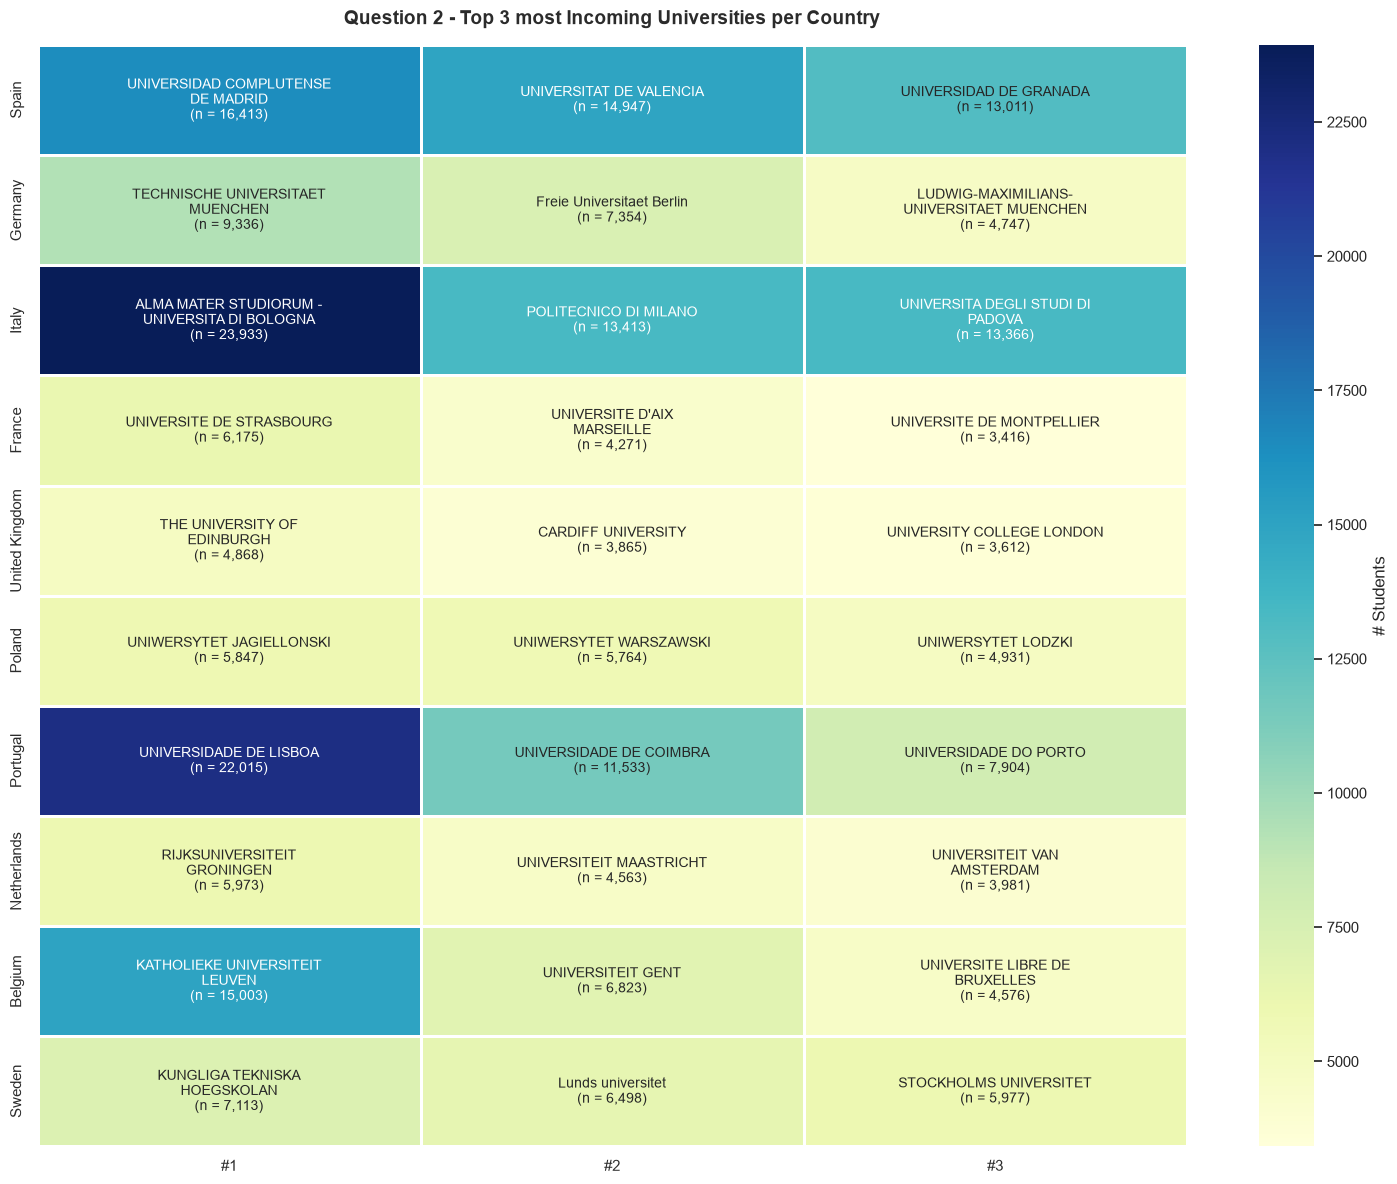

In [21]:
# Identify the top 10 receiving countries by TOTAL volume
top_countries = df['Receiving Country'].value_counts().head(10).index

# Filter out invalid university names
univ_column = 'Receiving Organization'
is_valid_org = (
    df[univ_column].notna() &                                      
    (df[univ_column].astype(str).str.strip() != '') &              
    (df[univ_column].astype(str).str.strip() != '-') &             
    (~df[univ_column].astype(str).str.upper().isin(['N/D', 'N/A', 'UNKNOWN'])) 
)
df_valid_orgs = df[is_valid_org]

# Build Matrices
mat = pd.DataFrame(index=top_countries, columns=['#1', '#2', '#3'], dtype=float)
labels = pd.DataFrame(index=top_countries, columns=['#1', '#2', '#3'], dtype=object)

for c in top_countries:
    sub = df_valid_orgs[df_valid_orgs['Receiving Country'] == c]
    top3 = sub[univ_column].value_counts().head(3)
    
    for i, (org, n) in enumerate(top3.items()):
        mat.loc[c, f'#{i+1}'] = n
        
        # FIX: Wrap text dynamically every 25 characters instead of slicing it
        wrapped_org_name = textwrap.fill(str(org), width = 25, max_lines = 4)
        
        labels.loc[c, f'#{i+1}'] = f"{wrapped_org_name}\n(n = {int(n):,})"

mat = mat.fillna(0)
labels = labels.fillna('')

# Plot
plt.figure(figsize=(15, 12)) 
plt.rcParams['font.family'] = 'sans-serif'

ax = sns.heatmap(
    mat, 
    annot=labels, 
    fmt='', 
    cmap='YlGnBu', 
    linewidths=0.8, 
    linecolor='white',
    cbar_kws={'label': '# Students'}, 
    annot_kws={'fontsize': 10, 'weight': 'normal'}
    )

ax.set_title('Question 2 - Top 3 most Incoming Universities per Country', 
             fontsize=14, pad=15, weight='bold', color='#2b2b2b')
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis='both', which='major', labelsize=11, labelcolor='#2b2b2b', )

plt.tight_layout()
plt.savefig("Plots/Question 2 - Top 3 most Incoming Universities per Country.png", dpi=800, bbox_inches="tight")
plt.show()

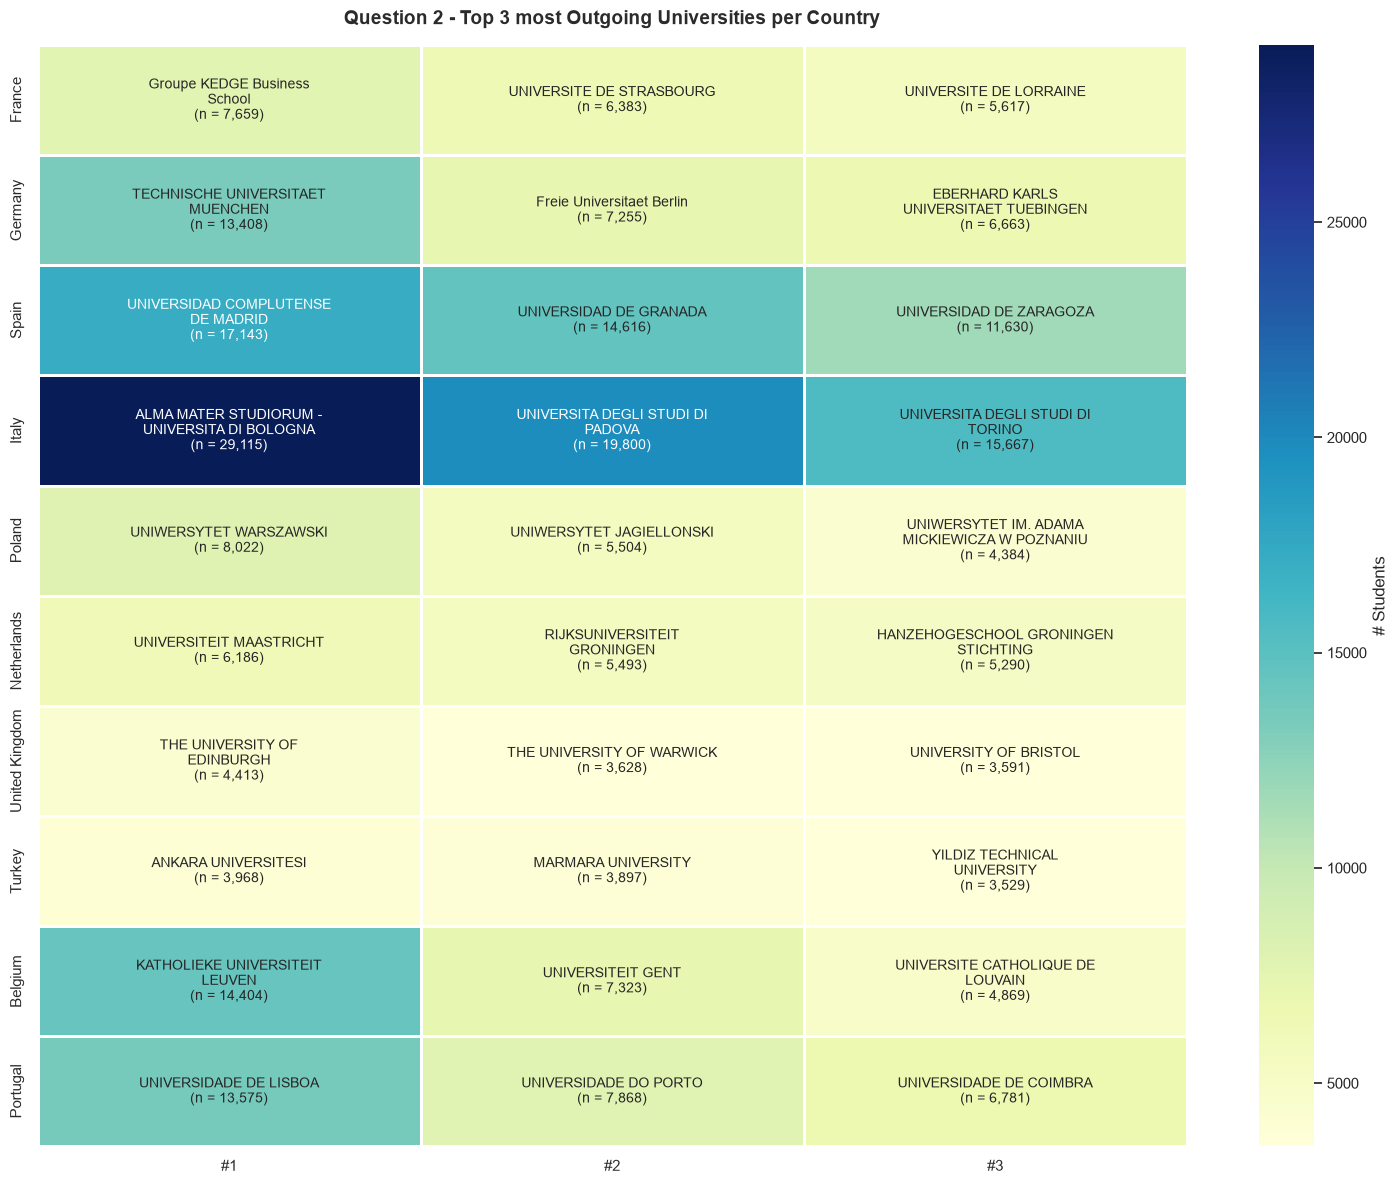

In [22]:
# Identify the top 15 receiving countries by TOTAL volume
top_countries = df['Sending Country'].value_counts().head(10).index

# Filter out invalid university names
univ_column = 'Sending Organization'
is_valid_org = (
    df[univ_column].notna() &                                      
    (df[univ_column].astype(str).str.strip() != '') &              
    (df[univ_column].astype(str).str.strip() != '-') &             
    (~df[univ_column].astype(str).str.upper().isin(['N/D', 'N/A', 'UNKNOWN'])) 
)
df_valid_orgs = df[is_valid_org]

# Build Matrices
mat = pd.DataFrame(index=top_countries, columns=['#1', '#2', '#3'], dtype=float)
labels = pd.DataFrame(index=top_countries, columns=['#1', '#2', '#3'], dtype=object)

for c in top_countries:
    sub = df_valid_orgs[df_valid_orgs['Sending Country'] == c]
    top3 = sub[univ_column].value_counts().head(3)
    
    for i, (org, n) in enumerate(top3.items()):
        mat.loc[c, f'#{i+1}'] = n
        
        # FIX: Wrap text dynamically every 20 characters instead of slicing it
        wrapped_org_name = textwrap.fill(str(org), width = 25, max_lines = 4)
        
        labels.loc[c, f'#{i+1}'] = f"{wrapped_org_name}\n(n = {int(n):,})"

mat = mat.fillna(0)
labels = labels.fillna('')

# Plot
plt.figure(figsize=(15, 12)) 
plt.rcParams['font.family'] = 'sans-serif'

ax = sns.heatmap(
    mat, 
    annot=labels, 
    fmt='', 
    cmap='YlGnBu', 
    linewidths=0.8, 
    linecolor='white',
    cbar_kws={'label': '# Students'}, 
    annot_kws={'fontsize': 10, 'weight': 'normal'}
    )

ax.set_title('Question 2 - Top 3 most Outgoing Universities per Country', 
             fontsize=14, pad=15, weight='bold', color='#2b2b2b')
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis='both', which='major', labelsize=11, labelcolor='#2b2b2b')

plt.tight_layout()
plt.savefig("Plots/Question 2 - Top 3 most Outgoing Universities per Country.png", dpi=800, bbox_inches="tight")
plt.show()

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
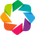

:Chord   [source,target]   (value)

In [23]:
# Initialize the Holoviews extension (uses Bokeh for circular interactivity)
hv.extension('bokeh')


top10 = df['Sending Country'].value_counts().head(10).index
flows_ct = df.groupby(['Sending Country', 'Receiving Country']).size().rename('n').reset_index()
flows_ct = flows_ct[flows_ct['Sending Country'].isin(top10) & flows_ct['Receiving Country'].isin(top10)]
flows_ct = flows_ct[flows_ct['n'] >= 2].sort_values('n', ascending=False)

chord_data = flows_ct.rename(columns={
    'Sending Country': 'source',
    'Receiving Country': 'target',
    'n': 'value'
})

palette = ['#e07a5f', '#3d5a80', '#81b29a', '#f2cc8f', '#e9c46a', 
           '#457b9d', '#2a9d8f', '#e63946', '#f4a261', '#264653']


# Holoviews natively groups source and destination into a single unified node
chord = hv.Chord(chord_data)

# Customized visual options
chord.opts(
    opts.Chord(
        title="Question 1 - Erasmus Macro-Flows (Top 10 Countries)",
        cmap=palette,                # Color palette for the outer nodes
        edge_cmap=palette,           # Color palette for the inner connecting ribbons
        edge_color=hv.dim('source').str(), # Color flows based on where they originate
        node_color=hv.dim('index').str(),  # Color nodes uniquely
        edge_alpha=0.6,              # Makes ribbons pleasantly transparent
        edge_hover_line_color='black', # Highlights the borders on hover
        node_size=15,
        labels='index',              # Displays country codes on the circumference
        width=700,
        height=700,
    )
)

# Render
chord

In [37]:
# Save the chord diagram as a static PNG image
hv.extension('matplotlib')

chord_mpl = hv.Chord(chord_data).opts(
    opts.Chord(
        title="Question 1 - Erasmus Macro-Flows (Top 10 Countries)",
        cmap=palette,
        edge_cmap=palette,
        edge_color=hv.dim('source').str(),
        node_color=hv.dim('index').str(),
        labels='index',
        fig_size=300,
    )
)

hv.save(chord_mpl, 'Plots/Question 1 - Erasmus Macro-Flows (Top 10 Countries).png', fmt='png', dpi=500)

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

ITALY

In [40]:
it = df[df['Sending Country']=='Italy']
yearly_it = it.groupby('Academic Year').size().reindex(range(2014,2024), fill_value=0)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(yearly_it.index, yearly_it.values, marker='o', color='#2a9d8f', linewidth=2, label='Italian Students (sample)')
z = np.polyfit(yearly_it.index, yearly_it.values, 1)
ax.plot(yearly_it.index, np.poly1d(z)(yearly_it.index), '--', color='gray', label='Linear Trend')
ax.axvspan(2019.9, 2021.1, color='red', alpha=0.25, label='COVID-19')
ax.set_title('Question 1 - Health of the Erasmus Project in Italy: Evolution of Outgoing Students')
ax.set_xlabel('Academic Year'); ax.set_ylabel('Number of Students'); ax.legend()

plt.tight_layout(); 
plt.savefig("Plots/Question 1 - Health of the Erasmus Project in Italy - Evolution of Outgoing Students.png", dpi=800, bbox_inches="tight")
plt.show()

C:\Users\rpasq\AppData\Local\Temp\ipykernel_8076\884876590.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [26]:
it = df[df['Receiving Country']=='Italy']
yearly_it = it.groupby('Academic Year').size().reindex(range(2014,2024), fill_value=0)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(yearly_it.index, yearly_it.values, marker='o', color='#2a9d8f', linewidth=2, label='Italian Students (sample)')
z = np.polyfit(yearly_it.index, yearly_it.values, 1)
ax.plot(yearly_it.index, np.poly1d(z)(yearly_it.index), '--', color='gray', label='Linear Trend')
ax.axvspan(2019.9, 2021.1, color='red', alpha=0.25, label='COVID-19')
ax.set_title('Question 1 - Health of the Erasmus Project in Italy: Evolution of Incoming Students')
ax.set_xlabel('Academic Year'); ax.set_ylabel('Number of Students'); ax.legend()

plt.tight_layout(); 
plt.savefig("Plots/Question 1 - Health of the Erasmus Project in Italy - Evolution of Incoming Students.png", dpi=800, bbox_inches="tight")
plt.show()

C:\Users\rpasq\AppData\Local\Temp\ipykernel_8076\2415253812.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Valutasre correlazione crescita It vs EU

In [27]:
cities = {
    'Turin': ["UNIVERSITA DEGLI STUDI DI TORINO", "POLITECNICO DI TORINO"],
    'Milan': ["POLITECNICO DI MILANO", "UNIVERSITA DEGLI STUDI DI MILANO", "UNIVERSITA COMMERCIALE LUIGI BOCCONI"],
    'Bologna': ["ALMA MATER STUDIORUM - UNIVERSITA DI BOLOGNA"],
    'Rome': ["UNIVERSITA DEGLI STUDI DI ROMA LA SAPIENZA", "UNIVERSITA DEGLI STUDI ROMA TRE", "UNIVERSITA DEGLI STUDI DI ROMA TOR VERGATA"],
    'Naples': ["UNIVERSITA DEGLI STUDI DI NAPOLI FEDERICO II.", "UNIVERSITA DEGLI STUDI DI NAPOLI PARTHENOPE", "UNIVERSITA DEGLI STUDI DI NAPOLI L'ORIENTALE"]
}

years = list(range(2014, 2024))

rows = []
for year in years:
    for city, universities in cities.items():
        value = 0
        for uni in universities:
            df_uni = pd.DataFrame()
            df_uni = df[(df['Receiving Organization'] == uni) & (df['Academic Year'] == year)].copy()
            value += len(df_uni)
        rows.append({'Year': str(year), 'City': city, 'Value': value})

data = pd.DataFrame(rows)
# print(data.head())
# print(df['Academic Year'].unique())
# print(df['Academic Year'].dtype)

palette = {'Turin': '#1d3557', 'Milan': '#e63946', 'Bologna': '#2a9d8f',
           'Rome': '#e9c46a', 'Naples': '#6a4c93'}

plt.figure(figsize=(11, 11))
plot = sp.spiderplot(x="Year", y="Value", hue="City", legend=True,
                      data=data, palette=palette, rref=0, alpha=1)
plot.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10, prop={'size': 13})
plot.set_title("Incoming Erasmus Students per University City (2014-2023)",
               y=1.08, fontsize=20, horizontalalignment='center', verticalalignment='center')
plt.tight_layout()
plt.savefig("Plots/Incoming Erasmus Students per University City (2014-2023).png", dpi=800, bbox_inches="tight")
plt.show()

C:\Users\rpasq\AppData\Local\Temp\ipykernel_8076\2416946127.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


graphs

UMIL

In [36]:
it = df[df['Sending Organization']=='UNIVERSITA DEGLI STUDI DI MILANO']
yearly_it = it.groupby('Academic Year').size().reindex(range(2014,2024), fill_value=0)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(yearly_it.index, yearly_it.values, marker='o', color='#2a9d8f', linewidth=2, label='UniMi Students')
z = np.polyfit(yearly_it.index, yearly_it.values, 1)
ax.plot(yearly_it.index, np.poly1d(z)(yearly_it.index), '--', color='gray', label='Linear Trend')
ax.axvspan(2019.9, 2021.1, color='red', alpha=0.25, label='COVID-19')
ax.set_title('Question 1 - Health of the Erasmus Project: Outgoing Students from UniMi')
ax.set_xlabel('Academic Year'); ax.set_ylabel('Number of Students'); ax.legend()

plt.tight_layout();
plt.savefig("Plots/Question 1 - Health of the Erasmus Project - Outgoing Students from UniMi.png", dpi=800, bbox_inches="tight")
plt.show()

C:\Users\rpasq\AppData\Local\Temp\ipykernel_8076\3904159291.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [29]:
it = df[df['Receiving Organization']=='UNIVERSITA DEGLI STUDI DI MILANO']
yearly_it = it.groupby('Academic Year').size().reindex(range(2014,2024), fill_value=0)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(yearly_it.index, yearly_it.values, marker='o', color='#2a9d8f', linewidth=2, label='UniMi Students')
z = np.polyfit(yearly_it.index, yearly_it.values, 1)
ax.plot(yearly_it.index, np.poly1d(z)(yearly_it.index), '--', color='gray', label='Linear Trend')
ax.axvspan(2019.9, 2021.1, color='red', alpha=0.25, label='COVID-19')
ax.set_title('Question 1 - Health of the Erasmus Project: Incoming Students to UniMi')
ax.set_xlabel('Academic Year'); ax.set_ylabel('Number of Students'); ax.legend()

plt.tight_layout();
plt.savefig("Plots/Question 1 - Health of the Erasmus Project - Incoming Students to UniMi.png", dpi=800, bbox_inches="tight")
plt.show()

C:\Users\rpasq\AppData\Local\Temp\ipykernel_8076\3445900693.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [30]:
# Define lists of exact raw string values present in the map
unimi_exact = ["UNIVERSITA DEGLI STUDI DI MILANO"]
polimi_exact = ["POLITECNICO DI MILANO"]
bocconi_exact = ["UNIVERSITA COMMERCIALE LUIGI BOCCONI"]
bicocca_exact = ["UNIVERSITA' DEGLI STUDI DI MILANO-BICOCCA"] # Exact key found with apostrophe
cattolica_exact = ["UNIVERSITA CATTOLICA DEL SACRO CUORE"]
iulm_exact = ["LIBERA UNIVERSITA DI LINGUE E COMUNICAZIONE IULM", "IULM"]
raffaele_exact = ["UNIVERSITA VITA-SALUTE SAN RAFFAELE"]

all_exact_names = (
    unimi_exact + polimi_exact + bocconi_exact + 
    bicocca_exact + cattolica_exact + iulm_exact + raffaele_exact
)

milan_senders = df[df['Sending Organization'].isin(all_exact_names)]
outgoing_counts = milan_senders['Sending Organization'].value_counts()

milan_receivers = df[df['Receiving Organization'].isin(all_exact_names)]
incoming_counts = milan_receivers['Receiving Organization'].value_counts()


df_out = outgoing_counts.reset_index(name='Outgoing')
df_out.columns = ['University', 'Outgoing']

df_in = incoming_counts.reset_index(name='Incoming')
df_in.columns = ['University', 'Incoming']

df_milan = pd.merge(df_out, df_in, on='University', how='outer').fillna(0)

def clean_milan_names(name):
    if name in polimi_exact:
        return 'PoliMi'
    elif name in bocconi_exact:
        return 'Bocconi'
    elif name in bicocca_exact:
        return 'UniMiB'
    elif name in cattolica_exact:
        return 'Cattolica'
    elif name in unimi_exact:
        return 'UNIMI'
    elif name in iulm_exact:
        return 'IULM'
    elif name in raffaele_exact:
        return 'San Raffaele'
    else:
        return textwrap.fill(str(name), width=25)

df_milan['Cleaned University'] = df_milan['University'].apply(clean_milan_names)

df_milan_grouped = df_milan.groupby('Cleaned University')[['Outgoing', 'Incoming']].sum().reset_index()


df_milan_grouped['Total'] = df_milan_grouped['Outgoing'] + df_milan_grouped['Incoming']
df_milan_top = df_milan_grouped.sort_values(by='Total', ascending=False).head(7)


df_molten = df_milan_top.melt(
    id_vars='Cleaned University', 
    value_vars=['Outgoing', 'Incoming'], 
    var_name='Students type', 
    value_name='Count'
)

# Plot
plt.figure(figsize=(12, 7.5))
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid')

ax = sns.barplot(
    data=df_molten,
    x='Cleaned University',
    y='Count',
    hue='Students type',
    palette=['#3d5a80', '#9b5de5']
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=9.5, color='#2b2b2b', weight='bold',
                    xytext=(0, 4),
                    textcoords='offset points')

# Polish the typography
ax.set_title('Top 7 Milan Universities per Direction of Flow: Outgoing Students vs Incoming Students', 
             fontsize=14, pad=20, weight='bold', color='#2b2b2b')
ax.set_xlabel('University', fontsize=12, labelpad=12, weight='bold', color='#2b2b2b')
ax.set_ylabel('Number of Students', fontsize=12, labelpad=12, weight='bold', color='#2b2b2b')

plt.xticks(rotation=0, horizontalalignment='center', fontsize=10, color='#2b2b2b')
plt.yticks(fontsize=10, color='#2b2b2b')
plt.legend(title='Direction of Flow', title_fontsize='11', fontsize='10', frameon=True)

plt.tight_layout()
plt.savefig("Plots/Top 7 Milan Universities per Direction of Flow - Outgoing Students vs Incoming Students.png", dpi=800, bbox_inches="tight")
plt.show()

C:\Users\rpasq\AppData\Local\Temp\ipykernel_8076\1145775611.py:99: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [31]:
unimi_incoming = df[df['Receiving Organization'] == "UNIVERSITA DEGLI STUDI DI MILANO"].copy()

# Count per Field of Education (simil CdL)
field_counts = unimi_incoming['Field of Education'].value_counts().reset_index()
field_counts.columns = ['Field of Education', 'Count']

field_counts_top = field_counts.head(15).copy()

field_counts_top['Wrapped Field'] = field_counts_top['Field of Education'].apply(
    lambda x: textwrap.fill(str(x), width=28)
)

# Plot
plt.figure(figsize=(14, 8.5))
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid')

ax = sns.barplot(
    data=field_counts_top,
    y='Wrapped Field',
    x='Count',
    color='#3d5a80',
    edgecolor='none'
)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f' {int(width):,}',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    fontsize=10, color='#2b2b2b', weight='bold',
                    xytext=(4, 0),
                    textcoords='offset points')

# Typography and aesthetics adjustments
ax.set_title('Incoming Students at UniMi by Field of Education (Top 15)', 
             fontsize=14, pad=20, weight='bold', color='#2b2b2b')
ax.set_xlabel('Number of Incoming Students', fontsize=11, labelpad=10, weight='bold', color='#2b2b2b')
ax.set_ylabel('Field of Education', fontsize=11, labelpad=10, weight='bold', color='#2b2b2b')

# Remove vertical clutter
ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.yaxis.grid(False)

plt.tight_layout()
plt.savefig("Plots/Incoming Students at UniMi by Field of Education (Top 15).png", dpi=800, bbox_inches="tight")
plt.show()

C:\Users\rpasq\AppData\Local\Temp\ipykernel_8076\1784644554.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [32]:
polimi_incoming = df[df['Receiving Organization'] == "POLITECNICO DI MILANO"].copy()


field_counts = polimi_incoming['Field of Education'].value_counts().reset_index()
field_counts.columns = ['Field of Education', 'Count']

field_counts_top = field_counts.head(15).copy()

field_counts_top['Wrapped Field'] = field_counts_top['Field of Education'].apply(
    lambda x: textwrap.fill(str(x), width=28)
)

plt.figure(figsize=(14, 8.5))
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid')


ax = sns.barplot(
    data=field_counts_top,
    y='Wrapped Field',
    x='Count',
    color='#3d5a80',
    edgecolor='none'
)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f' {int(width):,}',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    fontsize=10, color='#2b2b2b', weight='bold',
                    xytext=(4, 0),
                    textcoords='offset points')

# Typography and aesthetics adjustments
ax.set_title('Incoming Students at PoliMi by Field of Education (Top 15)', 
             fontsize=14, pad=20, weight='bold', color='#2b2b2b')
ax.set_xlabel('Number of Incoming Students', fontsize=11, labelpad=10, weight='bold', color='#2b2b2b')
ax.set_ylabel('Field of Education', fontsize=11, labelpad=10, weight='bold', color='#2b2b2b')

# Remove vertical clutter
ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.yaxis.grid(False)

plt.tight_layout()
plt.savefig("Plots/Incoming Students at PoliMi by Field of Education (Top 15).png", dpi=800, bbox_inches="tight")
plt.show()

C:\Users\rpasq\AppData\Local\Temp\ipykernel_8076\826074229.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [33]:
UniBo_incoming = df[df['Receiving Organization'] == "ALMA MATER STUDIORUM - UNIVERSITA DI BOLOGNA"].copy()


field_counts = UniBo_incoming['Field of Education'].value_counts().reset_index()
field_counts.columns = ['Field of Education', 'Count']

field_counts_top = field_counts.head(15).copy()

field_counts_top['Wrapped Field'] = field_counts_top['Field of Education'].apply(
    lambda x: textwrap.fill(str(x), width=28)
)

plt.figure(figsize=(14, 8.5))
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid')


ax = sns.barplot(
    data=field_counts_top,
    y='Wrapped Field',
    x='Count',
    color='#3d5a80',
    edgecolor='none'
)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f' {int(width):,}',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    fontsize=10, color='#2b2b2b', weight='bold',
                    xytext=(4, 0),
                    textcoords='offset points')

# Typography and aesthetics adjustments
ax.set_title('Incoming Students at UniBo by Field of Education (Top 15)', 
             fontsize=14, pad=20, weight='bold', color='#2b2b2b')
ax.set_xlabel('Number of Incoming Students', fontsize=11, labelpad=10, weight='bold', color='#2b2b2b')
ax.set_ylabel('Field of Education', fontsize=11, labelpad=10, weight='bold', color='#2b2b2b')

# Remove vertical clutter
ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.yaxis.grid(False)

plt.tight_layout()
plt.savefig("Plots/Incoming Students at UniBo by Field of Education (Top 15).png", dpi=800, bbox_inches="tight")
plt.show()

C:\Users\rpasq\AppData\Local\Temp\ipykernel_8076\126796929.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
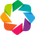

:Chord   [source,target]   (value)

In [34]:
hv.extension('bokeh')

# Define k for the top destinations
k = 20

df_umil = df[df['Sending Organization'] == "UNIVERSITA DEGLI STUDI DI MILANO"].copy()

invalid_orgs = ['-', '', 'N/D', 'N/A', 'UNKNOWN']
df_umil = df_umil[
    df_umil['Receiving Organization'].notna() &
    ~df_umil['Receiving Organization'].astype(str).str.upper().isin(invalid_orgs)
]

top_foreign_partners = df_umil['Receiving Organization'].value_counts().head(k).index


df_chord_umil = df_umil[df_umil['Receiving Organization'].isin(top_foreign_partners)]


flows_umil = df_chord_umil.groupby(['Sending Organization', 'Receiving Organization']).size().rename('n').reset_index()


chord_data = flows_umil.rename(columns={
    'Sending Organization': 'source',
    'Receiving Organization': 'target',
    'n': 'value'
})


palette = ['#e07a5f', '#3d5a80', '#81b29a', '#f2cc8f', '#e63946', 
           '#457b9d', '#2a9d8f', '#e9c46a', '#f4a261', '#264653',
           '#9b5de5', '#00bbf9', '#00f5d4', '#b5179e', '#4361ee',
           '#a8dadc', '#457b9d', '#1d3557', '#e63946', "#90eb72"]


chord_umil = hv.Chord(chord_data)

chord_umil.opts(
    opts.Chord(
        title=f"Mobilità Erasmus: Top {k} Destinazioni Preferite in Uscita da UNIMI",
        cmap=palette,
        edge_cmap=palette,
        edge_color=hv.dim('target').str(), # Colors ribbons dynamically based on the receiving destination
        node_color=hv.dim('index').str(),
        edge_alpha=0.6,
        edge_hover_line_color='black',
        node_size=12,
        labels='index',                    # Displays university names clearly on the outer ring
        width=850,                         # Wide layout so long foreign university names don't overlap
        height=850,
    )
)

chord_umil

In [35]:
# Directly copy and sort the already filtered chord dataframe
df_top_k = chord_data.copy().sort_values(by='value', ascending=False)
df_top_k['Wrapped Target'] = df_top_k['target'].apply(lambda x: textwrap.fill(str(x), width=35))


# Plot
plt.figure(figsize=(14, 8.5))
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid')

ax = sns.barplot(
    data=df_top_k,
    y='Wrapped Target',
    x='value',
    color= '#3d5a80',
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f' {int(width):,}',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    fontsize=9.5, color='#2b2b2b', weight='semibold',
                    xytext=(3, 0),
                    textcoords='offset points')

ax.set_title(f"Top {len(df_top_k)} Receiving Universities for Erasmus Mobility from UniMi", 
             fontsize=14, pad=20, weight='bold', color='#2b2b2b')
ax.set_xlabel('Number of Outgoing Students', fontsize=11, labelpad=10, weight='semibold', color='#2b2b2b')
ax.set_ylabel('Receiving University', fontsize=11, labelpad=10, weight='semibold', color='#2b2b2b')

ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.yaxis.grid(False)

plt.tight_layout()
plt.savefig(f"Plots/Top {len(df_top_k)} Receiving Universities for Erasmus Mobility from UniMi.png", dpi=800, bbox_inches="tight")
plt.show()

C:\Users\rpasq\AppData\Local\Temp\ipykernel_8076\1661596181.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Other vizs

Woah, UniMi è super sbilanciato!

Come mai? Proviamo a vedere se ci sono dati interessanti all'interno della composizione dei CdL per quanto riguarda gli studenti entranti

What about PoliMI?